# Penyeimbangan Data Ecoli ADASYN

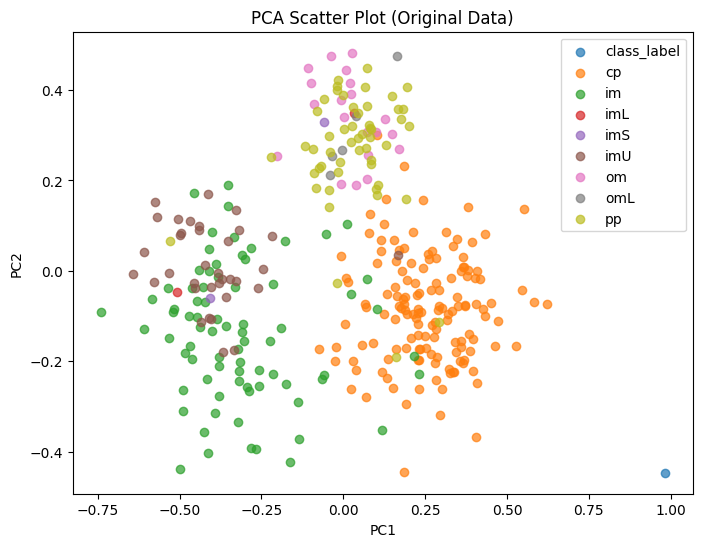

[('cp', 143), ('im', 153), ('imL', 142), ('imS', 142), ('imU', 145), ('om', 143), ('omL', 143), ('pp', 144)]
      principal component 1  principal component 2 class_label
0                  0.057602              -0.199646          im
1                 -0.151582              -0.298879          cp
2                 -0.030071              -0.382942          cp
3                 -0.033534              -0.207181          cp
4                 -0.084765              -0.204411          cp
...                     ...                    ...         ...
1150               0.048816              -0.186444          im
1151               0.261373               0.000066          im
1152               0.253904              -0.036645          im
1153               0.363659               0.044245          im
1154               0.378282              -0.000365          im

[1155 rows x 3 columns]


C:\Users\Jordan\AppData\Local\Temp\ipykernel_12364\2902477354.py:60: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10', len(targets))


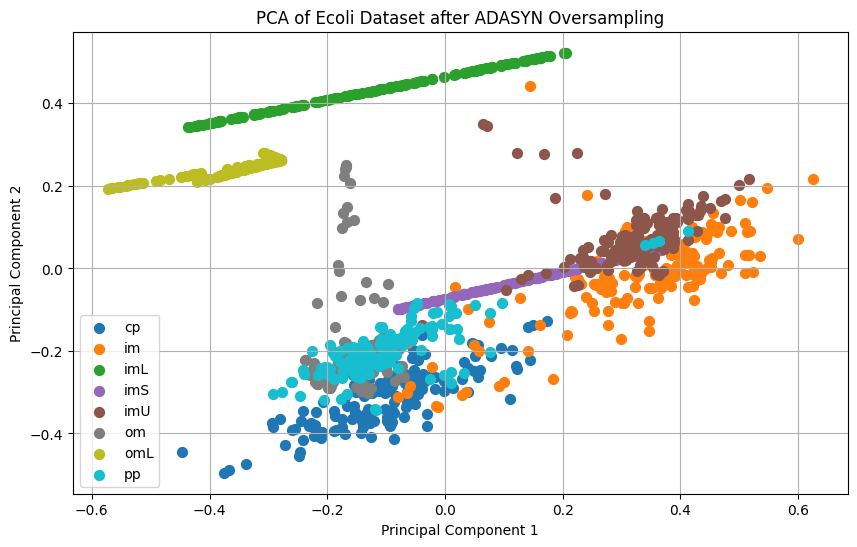

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sqlalchemy import create_engine
from collections import Counter
from imblearn.over_sampling import ADASYN  # 🔹 ganti ke ADASYN

# === 1. Koneksi ke MySQL XAMPP ===
engine = create_engine("mysql+pymysql://root:@localhost:3306/ecoli")

# ambil data dari tabel
df = pd.read_sql("SELECT * FROM ecoli;", engine)
class_counts = df['class_label'].value_counts().sort_index()
nt = df.drop(columns=["class_label", "id_protein"])
ns = df["class_label"]

# ==== PCA data asli ====

pca = PCA(n_components=2)
X_pca = pca.fit_transform(nt)

plt.figure(figsize=(8,6))
for label in np.unique(ns):
    idx = (ns == label)
    plt.scatter(X_pca[idx,0], X_pca[idx,1], label=label, alpha=0.7)
plt.title("PCA Scatter Plot (Original Data)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(); plt.show()

# ==== FIX DATA KOTOR ====
mask = ns != "class_label"
nt = nt[mask]
ns = ns[mask]

temp = sorted(class_counts)
temp.pop(0)

for i in range(0, 7):
    n = temp[i] - 1

    nt, ns = ADASYN(n_neighbors=n, sampling_strategy='minority').fit_resample(nt, ns)

df_resampled = pd.DataFrame(nt)  
df_resampled["class_label"] = ns  

df_resampled.to_csv("hasil_oversampling_ADASYN.csv", index=False)

print(f"{sorted(Counter(ns).items())}")

# === 2. PCA ===
pca = PCA(n_components=2)     
principalComponents = pca.fit_transform(nt)
principalDf = pd.DataFrame(data=principalComponents, columns=['principal component 1', 'principal component 2'])
finalDf = pd.concat([principalDf, ns.reset_index(drop=True)], axis=1)
print(finalDf)
# === 3. Visualisasi ===
fig, ax = plt.subplots(figsize=(10, 6))
targets = sorted(finalDf['class_label'].unique())
colors = plt.cm.get_cmap('tab10', len(targets))
for i, target in enumerate(targets):
    indicesToKeep = finalDf['class_label'] == target
    ax.scatter(finalDf.loc[indicesToKeep, 'principal component 1'], 
               finalDf.loc[indicesToKeep, 'principal component 2'], 
               c=[colors(i)], s=50, label=target)
ax.legend()
ax.grid()
plt.title('PCA of Ecoli Dataset after ADASYN Oversampling')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.show()

